<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/GN_GGN_Cross_Validation_Precision_Verification_Execution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/kimheeseo/LSCNS/blob/main/hcf_smf_g654e_optimal_gsnr_span_repeater_IMI_break.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open original in Colab"/></a>

# 논문 교차검증을 통한 작성 GN/GDF 코드의 정밀도 입증과 적용 한계 분석

## HCF · SMF · G.654.E: 원 GN vs GNmodelPJT GN/GGN vs Poggiolini EGN 논문

이 노트북은 원본 `hcf_smf_g654e_optimal_gsnr_span_repeater_IMI_break.ipynb`를 덮어쓰지 않는 **검증·확장본**이다.

1. 원본의 `gn_alpha_nli()`와 generalized-droop GSNR 계산 경로를 그대로 재현한다.
2. `GNmodelPJT/GN_model/GNLI_f_hyp.m` 및 `GNmodelPJT/GGN_model/GGNLI_f_3.m`의 의도된 적분을 Python으로 옮기고, 저장소 원문에서 발견된 다중 스팬 문제를 진단·보정한다.
3. 첨부 논문 *A Simple and Accurate Closed-Form EGN Model Formula*의 Figure 1, 2, 3 조건을 숫자로 대입하고, PDF에서 좌표화한 논문 곡선과 RMSE·편향·최대 오차를 비교한다.
4. 마지막 셀에서 입력값, 핵심 출력값, 시사점을 자동으로 정리한다.

> **중요한 모델 구분** — 저장소의 GGN은 arbitrary power profile/SRS를 다루는 *generalized GN*이며, 변조 포맷의 비가우시안성을 보정하는 논문의 *EGN*과는 다른 모델이다. 따라서 flat/no-SRS 조건에서 올바른 GGN은 GN과 같아지는 것이 정상이다.

## 0. 검증 원칙과 판정 기준

- 원 코드의 폐형식 GN은 수정하지 않고 동일 식으로 호출한다.
- MATLAB 이식판은 저장소의 단위 규약(주파수 THz, 거리 km, $\beta_2$ ps²/km, PSD W/THz)을 따른다.
- `GNLI_f_hyp.m`은 이름과 달리 `GNLI_f.m` 호출 래퍼이므로 별도 hyperbolic-domain 적분으로 간주하지 않는다.
- `GGNLI_f_3.m`도 `GGNLI_f.m` 호출 래퍼이며, 원문 `GGNLI_f.m`에는 `sys.Ns`가 사용되지 않는다.
- 논문 곡선은 제공 PDF의 래스터 Figure에서 지정된 $N_{span}$ 또는 $\Delta f$ 위치를 좌표화했다. 선 두께를 고려한 판독 불확도는 Figure 1·2 약 ±0.3 dB, Figure 3 약 ±0.1 dB-reach 수준이다.
- Figure 3의 오차는 논문 표현에 맞춰 $10\log_{10}(N_{pred}/N_{paper})$ [dB]로 계산한다.

In [1]:
import math
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erfcinv

try:
    from IPython.display import display, Markdown
except ImportError:
    class Markdown(str):
        pass

    def display(*objects):
        # The local verification runner prints deterministic text; Colab uses rich display.
        for obj in objects:
            if isinstance(obj, pd.DataFrame):
                print(obj.to_string(index=False))
            else:
                print(obj)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "lines.linewidth": 1.8,
})

def db_to_lin(x_db):
    return 10.0 ** (np.asarray(x_db, dtype=float) / 10.0)

def lin_to_db(x):
    return 10.0 * np.log10(np.asarray(x, dtype=float))

def dbm_to_w(x_dbm):
    return 1e-3 * db_to_lin(x_dbm)

def w_to_dbm(x_w):
    return lin_to_db(np.asarray(x_w, dtype=float) / 1e-3)

H_PLANCK = 6.62607015e-34
C_M_PER_S = 299_792_458.0
C_NM_PER_S = 2.99792458e17
print("Imports and unit helpers: PASS")

Imports and unit helpers: PASS


## 1. 원 Colab의 입력과 GN/GDF 계산 경로

아래 HCF 값(0.075 dB/km, 3.2 ps/nm/km)은 원 Colab의 DNANF geometry/보정 셀이 산출한 1550-nm 결과다. GN 비교의 독립변수만 분리하기 위해 이 검증본에서는 그 최종값을 입력으로 사용한다. 나머지 시스템·섬유 값과 GDF 식은 원본과 동일하다.

In [2]:
@dataclass(frozen=True)
class FibreParameters:
    key: str
    label: str
    attenuation_db_per_km: float
    dispersion_ps_nm_km: float
    gamma_per_w_km: float
    effective_area_um2: float | None = None
    imi_db_per_km: float | None = None

    @property
    def imi_linear_per_km(self):
        return 0.0 if self.imi_db_per_km is None else 10.0 ** (self.imi_db_per_km / 10.0)

@dataclass(frozen=True)
class SystemParameters:
    wavelength_nm: float = 1550.0
    noise_figure_db: float = 4.5
    symbol_rate_hz: float = 100e9
    channel_spacing_hz: float = 112.5e9
    bandwidth_hz: float = 4.3e12
    pfe_voltage_v: float = 18e3
    conductor_resistance_ohm_per_km: float = 1.0
    circuit_fraction: float = 0.10
    fibre_pairs: int = 12
    nl_backoff_db: float = 2.0
    launch_power_limit_dbm: float = 18.0

    @property
    def n_channels(self):
        return self.bandwidth_hz / self.channel_spacing_hz

SYSTEM = SystemParameters()
FIBRES = {
    "HCF": FibreParameters("HCF", "DNANF HCF", 0.075, 3.2, 5e-4, None, -52.0),
    "SMF": FibreParameters("SMF", "SMF (G.652.D)", 0.18, 18.0, 1.30, 85.0, None),
    "G654E": FibreParameters("G654E", "G.654.E (SCUBA 110)", 0.15, 21.0, 0.81, 110.0, None),
}

system_input_table = pd.DataFrame([
    ("wavelength", SYSTEM.wavelength_nm, "nm"),
    ("NF", SYSTEM.noise_figure_db, "dB"),
    ("Rs", SYSTEM.symbol_rate_hz/1e9, "GBaud"),
    ("channel spacing", SYSTEM.channel_spacing_hz/1e9, "GHz"),
    ("optical bandwidth", SYSTEM.bandwidth_hz/1e12, "THz"),
    ("effective Nch", SYSTEM.n_channels, "channels"),
    ("PFE voltage", SYSTEM.pfe_voltage_v/1e3, "kV"),
    ("fibre pairs", SYSTEM.fibre_pairs, "pairs"),
], columns=["System input", "Value", "Unit"])

fibre_input_table = pd.DataFrame([{
    "Fibre": f.label,
    "alpha [dB/km]": f.attenuation_db_per_km,
    "D [ps/nm/km]": f.dispersion_ps_nm_km,
    "gamma [1/W/km]": f.gamma_per_w_km,
    "Aeff [um2]": f.effective_area_um2,
    "IMI [dB/km]": f.imi_db_per_km,
} for f in FIBRES.values()])

display(system_input_table)
display(fibre_input_table)

,System input,Value,Unit
0,wavelength,1550.000000,nm
1,NF,4.500000,dB
2,Rs,100.000000,GBaud
3,channel spacing,112.500000,GHz
4,optical bandwidth,4.300000,THz
5,effective Nch,38.222222,channels
6,PFE voltage,18.000000,kV
7,fibre pairs,12.000000,pairs


,Fibre,alpha [dB/km],D [ps/nm/km],gamma [1/W/km],Aeff [um2],IMI [dB/km]
0,DNANF HCF,0.075,3.2,0.0005,NaN,-52.0
1,SMF (G.652.D),0.180,18.0,1.3000,85.0,NaN
2,G.654.E (SCUBA 110),0.150,21.0,0.8100,110.0,NaN


In [3]:
def span_count_and_length(total_length_km, nominal_span_km):
    n_repeaters = max(1, int(np.floor(total_length_km / nominal_span_km)))
    return n_repeaters, total_length_km / n_repeaters

def beta2_ps2_km_from_D(D_ps_nm_km, wavelength_nm=1550.0):
    return -(D_ps_nm_km * wavelength_nm**2) / (2*np.pi*299_792.458)

def gn_alpha_nli_original(actual_span_km, fibre, system=SYSTEM):
    # 원 Colab gn_alpha_nli()의 식을 그대로 재현한 단일-span 계수 [1/W^2].
    alpha_lin = fibre.attenuation_db_per_km / 4.343
    dispersion_s_per_km_nm = fibre.dispersion_ps_nm_km * 1e-12
    beta2 = abs(-dispersion_s_per_km_nm * system.wavelength_nm**2 /
                (2*np.pi*C_NM_PER_S))
    leff = (1-np.exp(-alpha_lin*actual_span_km))/alpha_lin
    leff_asymptotic = 1/alpha_lin
    arg = (np.pi**2/2 * beta2 * leff_asymptotic * system.symbol_rate_hz**2
           * system.n_channels**(2*system.symbol_rate_hz/system.channel_spacing_hz))
    return ((8/27)*fibre.gamma_per_w_km**2*leff**2*np.arcsinh(arg) /
            (np.pi*beta2*leff_asymptotic*system.symbol_rate_hz**2))

def generalized_droop_gsnr_with_alpha(total_launch_power_w, total_length_km,
                                       nominal_span_km, fibre, alpha_nli,
                                       system=SYSTEM):
    # 원 generalized-droop 경로. alpha_nli만 모델별로 주입한다.
    ps = np.asarray(total_launch_power_w, dtype=float)
    n_repeaters, actual_span_km = span_count_and_length(total_length_km, nominal_span_km)
    pch = ps/system.n_channels
    nu = C_NM_PER_S/system.wavelength_nm
    span_gain = db_to_lin(fibre.attenuation_db_per_km*actual_span_km)
    pase = H_PLANCK*nu*db_to_lin(system.noise_figure_db)*system.symbol_rate_hz*(span_gain-1)
    chi_a = 1/(1+pase/pch)
    chi_r = 1/(1+alpha_nli*pch**2+fibre.imi_linear_per_km*actual_span_km)
    exponent = n_repeaters*(-np.log(chi_a)-np.log(chi_r))
    return 1/np.expm1(np.minimum(exponent, 700))

for f in FIBRES.values():
    assert gn_alpha_nli_original(75, f) > 0
print("Original closed-form GN/GDF path: PASS")

Original closed-form GN/GDF path: PASS


## 2. GNmodelPJT MATLAB 모델의 이식과 이론적 수정

### 원문 검토 결과

| 파일 | 실제 동작 | 이론 검증 | 이 검증본의 처리 |
|---|---|---|---|
| `GNLI_f_hyp.m` | `GNLI_f(...)` 호출만 수행 | hyperbolic 적분이 아님 | Cartesian 적분으로 명시 |
| `GNLI_f.m` | $db=j\Delta\beta$를 만든 뒤 `sin(db·...)` 사용 | imaginary sine가 되어 다중 span에서 비물리적 exponential/overflow 가능 | `sin(Δβ·... )` 또는 geometric phase sum 사용 |
| `GGNLI_f_3.m` | `GGNLI_f(...)` 호출만 수행 | wrapper 자체는 정상 | 본체의 power-profile 적분을 이식 |
| `GGNLI_f.m` | arbitrary $\rho(z,f)$ 적분 | `sys.Ns`를 사용하지 않아 single-span만 반환 | single-span을 명시하고, 비교 시 incoherent $N_s$ 누적 |

GGN link function은

$$
\mu(f_1,f_2,f)=\int_0^{L_s}\sqrt{\frac{\rho(z,f_1)\rho(z,f_2)\rho(z,f_1+f_2-f)}{\rho(z,f)}}
e^{j\Delta\beta z}\,dz
$$

로 구현한다. flat loss $\rho=e^{-\alpha z}$이면 적분핵은 $e^{-\alpha z}$가 되어 GN의 lossy-span field integral과 일치한다.

In [4]:
def rectangular_wdm_psd(f_thz, n_ch, rs_thz, spacing_thz, rolloff=0.0, pch_w=1.0):
    # Rectangular WDM PSD [W/THz]. n_ch is odd so that CUT is at 0.
    f = np.asarray(f_thz)
    bw = rs_thz*(1+rolloff)
    centers = spacing_thz*np.arange(-(n_ch//2), n_ch//2+1)
    out = np.zeros_like(f, dtype=float)
    for fc in centers:
        out += (np.abs(f-fc) <= bw/2)*(pch_w/bw)
    return out

def gnli_psd_cartesian_single_span(f_eval_thz, fibre, span_km, n_ch, rs_thz,
                                   spacing_thz, rolloff=0.0, ngrid=321):
    # GNLI_f intent: one-span Cartesian GN NLI PSD [W/Hz] at Pch=1 W.
    bw = (n_ch-1)*spacing_thz + rs_thz*(1+rolloff)
    grid = np.linspace(-bw/2, bw/2, ngrid)
    f1, f2 = grid[:, None], grid[None, :]
    g = rectangular_wdm_psd(grid, n_ch, rs_thz, spacing_thz, rolloff)
    f3 = f1+f2-f_eval_thz
    g3 = rectangular_wdm_psd(f3, n_ch, rs_thz, spacing_thz, rolloff)
    beta2 = beta2_ps2_km_from_D(fibre.dispersion_ps_nm_km)
    mismatch = 4*np.pi**2*beta2*(f1-f_eval_thz)*(f2-f_eval_thz)
    alpha_p = fibre.attenuation_db_per_km/4.343
    link = (1-np.exp((-alpha_p+1j*mismatch)*span_km))/(alpha_p-1j*mismatch)
    integrand = np.abs(link)**2*g[:, None]*g[None, :]*g3
    # THz^2 integration and W/THz^3 -> W/THz; 1e-12 converts to W/Hz.
    return ((16/27)*fibre.gamma_per_w_km**2
            * np.trapezoid(np.trapezoid(integrand, grid, axis=1), grid)*1e-12)

def ggnli_psd_profile_single_span(f_eval_thz, fibre, span_km, n_ch, rs_thz,
                                  spacing_thz, rolloff=0.0, edge_tilt_db=0.0,
                                  ngrid=321, nz=61):
    # GGNLI_f intent: arbitrary normalized power profile, one span [W/Hz].
    bw = (n_ch-1)*spacing_thz + rs_thz*(1+rolloff)
    grid = np.linspace(-bw/2, bw/2, ngrid)
    f1, f2 = grid[:, None], grid[None, :]
    f3 = f1+f2-f_eval_thz
    g = rectangular_wdm_psd(grid, n_ch, rs_thz, spacing_thz, rolloff)
    g3 = rectangular_wdm_psd(f3, n_ch, rs_thz, spacing_thz, rolloff)
    beta2 = beta2_ps2_km_from_D(fibre.dispersion_ps_nm_km)
    mismatch = 4*np.pi**2*beta2*(f1-f_eval_thz)*(f2-f_eval_thz)
    alpha_p = fibre.attenuation_db_per_km/4.343
    # For rho(z,f)=exp(-alpha*z)*10^[edge_tilt_db*(f/(B/2))*(z/L)/10],
    # sqrt(rho1*rho2*rho3/rhoCUT) is an exponential in z.  Evaluate it exactly;
    # this removes z-grid aliasing and guarantees GGN(flat)==GN on the same f-grid.
    tilt_rate = (np.log(10)/10)*edge_tilt_db*(f3/(bw/2))/span_km
    effective_alpha = alpha_p-tilt_rate
    link = ((1-np.exp((-effective_alpha+1j*mismatch)*span_km)) /
            (effective_alpha-1j*mismatch))
    integrand = np.abs(link)**2*g[:, None]*g[None, :]*g3
    return ((16/27)*fibre.gamma_per_w_km**2
            * np.trapezoid(np.trapezoid(integrand, grid, axis=1), grid)*1e-12)

def eta_from_psd_function(psd_function, fibre, span_km, n_ch, rs_thz,
                          spacing_thz, rolloff=0.0, nf=3, **kwargs):
    f_eval = np.linspace(-rs_thz/2, rs_thz/2, nf)
    psd = np.array([psd_function(f, fibre, span_km, n_ch, rs_thz,
                                 spacing_thz, rolloff, **kwargs) for f in f_eval])
    return np.trapezoid(psd, f_eval)*1e12  # integrate over CUT Hz -> [1/W^2]

def raw_repo_span_factor_demo(mismatch_per_km, span_km, n_span):
    db = 1j*np.asarray(mismatch_per_km)
    with np.errstate(over="ignore", invalid="ignore", divide="ignore"):
        raw = np.abs(np.sin(db*n_span*span_km/2)/np.sin(db*span_km/2))**2
    x = np.asarray(mismatch_per_km)*span_km/2
    corrected = np.where(np.abs(np.sin(x)) < 1e-14, n_span**2,
                         np.abs(np.sin(n_span*x)/np.sin(x))**2)
    return raw, corrected

raw, corrected = raw_repo_span_factor_demo(np.array([0.01, 0.1, 1.0]), 100, 50)
repo_diagnostic = pd.DataFrame({
    "mismatch [1/km]": [0.01, 0.1, 1.0],
    "raw |sin(jx Ns)/sin(jx)|^2": raw,
    "corrected real-phase factor": corrected,
})
display(repo_diagnostic)
print("Repository literal diagnostic: raw factor can become exponentially large; corrected factor is bounded by Ns^2.")

,mismatch [1/km],raw |sin(jx Ns)/sin(jx)|^2,corrected real-phase factor
0,0.01,4.773421e+21,0.076211
1,0.10,6.372877e+212,1.024348
2,1.00,inf,6.139778


Repository literal diagnostic: raw factor can become exponentially large; corrected factor is bounded by Ns^2.


## 3. 원 해저 시스템 조건에서 모델 정확도·속도·GSNR 비교

- 총 길이 9,000 km, nominal span 75 km를 공통으로 사용한다.
- 원 시스템의 유효 채널 수 38.22는 수치 적분의 대칭 CUT를 위해 가장 가까운 홀수 39채널로 둔다. 원 폐형식은 원래의 38.22를 그대로 사용한다.
- GGN(flat)은 GN과의 등가성 시험, GGN(tilt)은 span 끝에서 +주파수 edge가 +1 dB, −edge가 −1 dB인 2-dB edge-to-edge stress test다.
- 속도 비교는 현재 런타임의 wall time이므로 절대 벤치마크가 아니라 모델 복잡도 비교다.

In [5]:
TOTAL_LENGTH_KM = 9000
NOMINAL_SPAN_KM = 75
NREP, ACTUAL_SPAN_KM = span_count_and_length(TOTAL_LENGTH_KM, NOMINAL_SPAN_KM)
NCH_NUMERIC = 39
RS_THz = SYSTEM.symbol_rate_hz/1e12
DF_THz = SYSTEM.channel_spacing_hz/1e12

benchmark_rows = []
model_alpha = {}
for key, fibre in FIBRES.items():
    t0 = time.perf_counter()
    eta_original = gn_alpha_nli_original(ACTUAL_SPAN_KM, fibre)
    t_original = time.perf_counter()-t0

    t0 = time.perf_counter()
    eta_gn = eta_from_psd_function(
        gnli_psd_cartesian_single_span, fibre, ACTUAL_SPAN_KM,
        NCH_NUMERIC, RS_THz, DF_THz, ngrid=321, nf=3)
    t_gn = time.perf_counter()-t0

    t0 = time.perf_counter()
    eta_ggn_flat = eta_from_psd_function(
        ggnli_psd_profile_single_span, fibre, ACTUAL_SPAN_KM,
        NCH_NUMERIC, RS_THz, DF_THz, edge_tilt_db=0.0, ngrid=321, nz=51, nf=3)
    t_flat = time.perf_counter()-t0

    t0 = time.perf_counter()
    eta_ggn_tilt = eta_from_psd_function(
        ggnli_psd_profile_single_span, fibre, ACTUAL_SPAN_KM,
        NCH_NUMERIC, RS_THz, DF_THz, edge_tilt_db=1.0, ngrid=321, nz=51, nf=3)
    t_tilt = time.perf_counter()-t0

    vals = {
        "Original closed GN": (eta_original, t_original),
        "GNmodelPJT GN (fixed)": (eta_gn, t_gn),
        "GNmodelPJT GGN flat (fixed)": (eta_ggn_flat, t_flat),
        "GNmodelPJT GGN 2-dB tilt": (eta_ggn_tilt, t_tilt),
    }
    model_alpha[key] = {name: value[0] for name, value in vals.items()}
    pgrid_dbm = np.linspace(-10, 24, 401)
    for name, (eta, runtime) in vals.items():
        curve = generalized_droop_gsnr_with_alpha(
            dbm_to_w(pgrid_dbm), TOTAL_LENGTH_KM, NOMINAL_SPAN_KM, fibre, eta)
        imax = int(np.argmax(curve))
        benchmark_rows.append({
            "Fibre": key, "Model": name,
            "eta_span [dB 1/W2]": float(lin_to_db(eta)),
            "delta eta vs original [dB]": float(lin_to_db(eta/eta_original)),
            "peak GSNR [dB]": float(lin_to_db(curve[imax])),
            "peak total launch [dBm]": float(pgrid_dbm[imax]),
            "runtime [ms]": 1e3*runtime,
        })

benchmark_df = pd.DataFrame(benchmark_rows)
numeric_reference = benchmark_df[
    benchmark_df["Model"] == "GNmodelPJT GN (fixed)"
][["Fibre", "eta_span [dB 1/W2]"]].rename(
    columns={"eta_span [dB 1/W2]": "numeric GN eta [dB 1/W2]"}
)
benchmark_df = benchmark_df.merge(numeric_reference, on="Fibre", how="left")
benchmark_df["delta eta vs numeric GN [dB]"] = (
    benchmark_df["eta_span [dB 1/W2]"]-benchmark_df["numeric GN eta [dB 1/W2]"]
)
display(benchmark_df.round(4))

flat_equiv = benchmark_df.pivot(index="Fibre", columns="Model", values="eta_span [dB 1/W2]")
flat_equiv_error_db = (flat_equiv["GNmodelPJT GGN flat (fixed)"]
                       - flat_equiv["GNmodelPJT GN (fixed)"]).abs()
print(f"GN vs flat-GGN maximum mismatch = {flat_equiv_error_db.max():.3f} dB")

,Fibre,Model,eta_span [dB 1/W2],delta eta vs original [dB],peak GSNR [dB],peak total launch [dBm],runtime [ms],numeric GN eta [dB 1/W2],delta eta vs numeric GN [dB]
0,HCF,Original closed GN,-37.7003,0.0000,12.1991,24.000,0.0465,-28.4786,-9.2217
1,HCF,GNmodelPJT GN (fixed),-28.4786,9.2217,12.1986,24.000,123.3763,-28.4786,0.0000
2,HCF,GNmodelPJT GGN flat (fixed),-28.4786,9.2217,12.1986,24.000,179.9196,-28.4786,0.0000
3,HCF,GNmodelPJT GGN 2-dB tilt,-28.4493,9.2510,12.1986,24.000,119.3328,-28.4786,0.0293
4,SMF,Original closed GN,22.0465,0.0000,9.6162,17.115,0.0289,34.5123,-12.4658
5,SMF,GNmodelPJT GN (fixed),34.5123,12.4658,5.0908,12.950,110.4474,34.5123,0.0000
6,SMF,GNmodelPJT GGN flat (fixed),34.5123,12.4658,5.0908,12.950,114.7595,34.5123,0.0000
7,SMF,GNmodelPJT GGN 2-dB tilt,34.5282,12.4816,5.0847,12.950,92.3902,34.5123,0.0158
8,G654E,Original closed GN,17.9168,0.0000,12.6984,17.710,0.0161,31.7023,-13.7856
9,G654E,GNmodelPJT GN (fixed),31.7023,13.7856,7.8869,13.120,77.0012,31.7023,0.0000


GN vs flat-GGN maximum mismatch = 0.000 dB


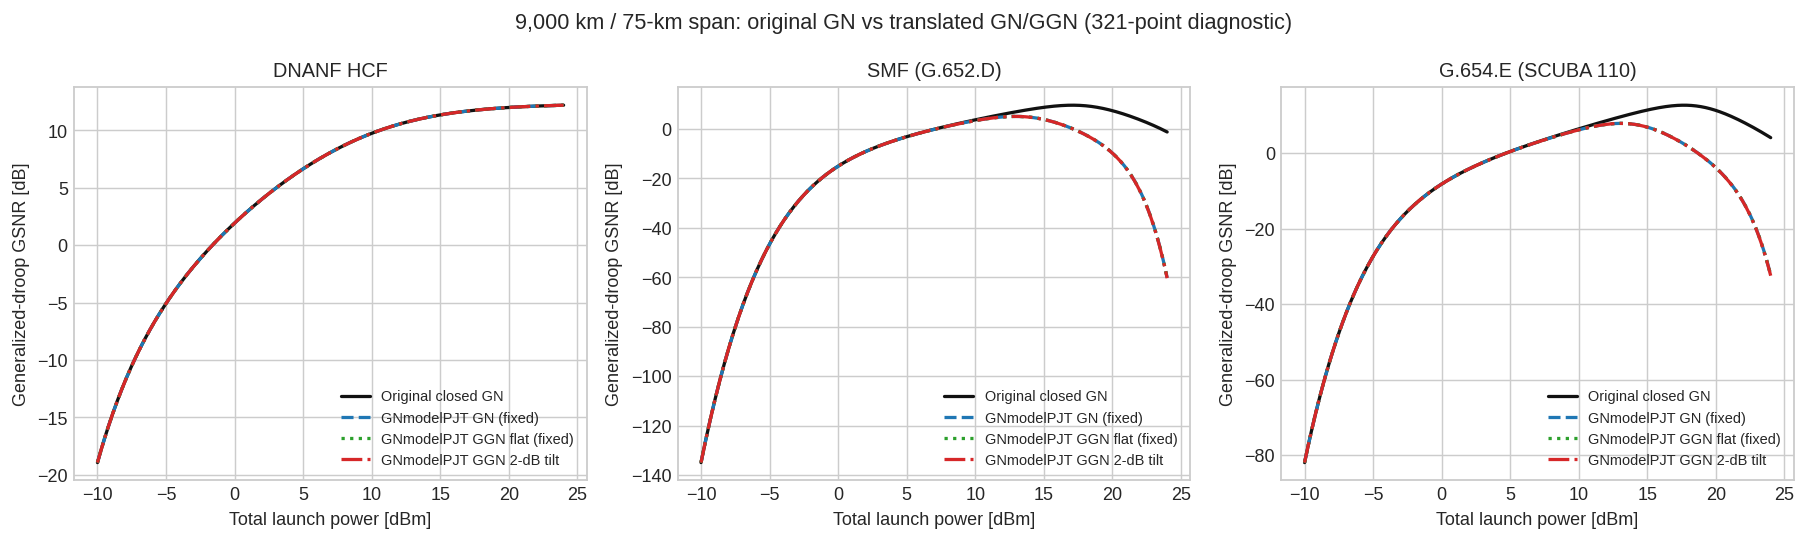

In [6]:
pgrid_dbm = np.linspace(-10, 24, 401)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharex=True)
styles = {
    "Original closed GN": ("#111111", "-"),
    "GNmodelPJT GN (fixed)": ("#1f77b4", "--"),
    "GNmodelPJT GGN flat (fixed)": ("#2ca02c", ":"),
    "GNmodelPJT GGN 2-dB tilt": ("#d62728", "-."),
}
for ax, (key, fibre) in zip(axes, FIBRES.items()):
    for name, eta in model_alpha[key].items():
        y = lin_to_db(generalized_droop_gsnr_with_alpha(
            dbm_to_w(pgrid_dbm), TOTAL_LENGTH_KM, NOMINAL_SPAN_KM, fibre, eta))
        ax.plot(pgrid_dbm, y, color=styles[name][0], ls=styles[name][1], label=name)
    ax.set_title(fibre.label)
    ax.set_xlabel("Total launch power [dBm]")
    ax.set_ylabel("Generalized-droop GSNR [dB]")
    ax.legend()
fig.suptitle("9,000 km / 75-km span: original GN vs translated GN/GGN (321-point diagnostic)")
fig.tight_layout()
plt.show()

## 4. 논문 Figure 1·2 조건과 폐형식 App.EGN-2

논문 입력:

- 32 GBaud, roll-off 0.05, spacing 33.6 GHz, 100-km span, noiseless
- Figure 1: 3 PM-QPSK channels
- Figure 2: 15 PM-QPSK channels
- SMF $(\alpha,D,\gamma)=(0.22,16.7,1.3)$
- NZDSF $(0.22,3.8,1.5)$
- LS $(0.22,-1.8,2.2)$, 단위 dB/km, ps/nm/km, 1/W/km
- QPSK modulation factor $\Phi=1$

논문의 Eq. (1), (3)을 center CUT의 적분 NLI 계수로 변환하면

$$\eta_{EGN2}\approx\eta_{GN}-\frac{80}{81}\frac{\Phi\gamma^2L_{eff}^2N_s}{R_s\Delta f\pi|\beta_2|L_s}
\left[H_{(N_{ch}-1)/2}+\frac{\Delta f}{R_s}\right].$$

원 코드의 $\eta_{GN}=N_s\eta_{span}$은 완전 선형 누적이므로, 저분산/소채널에서 논문 GN의 coherent accumulation을 재현하지 못한다. 이 때문에 Eq. (3)을 단순 차감한 결과는 LS 3-channel에서 특히 보수적으로 실패할 수 있으며, 그 실패도 숨기지 않고 표시한다.

In [7]:
@dataclass(frozen=True)
class PaperFibre:
    name: str
    alpha_db_km: float
    D_ps_nm_km: float
    gamma_w_km: float

PAPER_FIBRES = {
    "SMF": PaperFibre("SMF", 0.22, 16.7, 1.3),
    "NZDSF": PaperFibre("NZDSF", 0.22, 3.8, 1.5),
    "LS": PaperFibre("LS", 0.22, -1.8, 2.2),
}
PAPER_NS = np.array([1, 2, 5, 10, 20, 50])

def closed_gn_eta_total(n_ch, n_span, pf, span_km=100, rs_hz=32e9,
                        spacing_hz=33.6e9, wavelength_nm=1550):
    alpha_p = pf.alpha_db_km/4.343
    beta2_s2_km = abs(beta2_ps2_km_from_D(pf.D_ps_nm_km, wavelength_nm))*1e-24
    leff = (1-np.exp(-alpha_p*span_km))/alpha_p
    leff_inf = 1/alpha_p
    arg = (np.pi**2/2*beta2_s2_km*leff_inf*rs_hz**2
           * n_ch**(2*rs_hz/spacing_hz))
    eta_span = ((8/27)*pf.gamma_w_km**2*leff**2*np.arcsinh(arg) /
                (np.pi*beta2_s2_km*leff_inf*rs_hz**2))
    return n_span*eta_span

def harmonic_number(n):
    return float(np.sum(1/np.arange(1, n+1))) if n else 0.0

def paper_egn2_correction(n_ch, n_span, pf, phi=1.0, span_km=100,
                          rs_thz=0.032, spacing_thz=0.0336):
    alpha_p = pf.alpha_db_km/4.343
    leff = (1-np.exp(-alpha_p*span_km))/alpha_p
    beta2 = abs(beta2_ps2_km_from_D(pf.D_ps_nm_km))
    bracket = harmonic_number((n_ch-1)//2)+spacing_thz/rs_thz
    return ((80/81)*phi*pf.gamma_w_km**2*leff**2*n_span /
            (rs_thz*spacing_thz*np.pi*beta2*span_km)*bracket)

# Digitized from the provided PDF at Nspan=[1,2,5,10,20,50].
PAPER_FIG12 = {
    (3,"SMF"): {"GN":[26.92,30.08,34.42,37.68,41.07,45.15], "EGN":[22.31,26.72,32.29,35.68,39.34,43.77]},
    (15,"SMF"): {"GN":[29.78,32.82,37.04,40.16,43.34,47.32], "EGN":[24.52,28.91,34.56,38.11,41.56,45.98]},
    (3,"NZDSF"): {"GN":[32.20,35.53,40.13,43.52,46.97,51.28], "EGN":[28.42,32.07,37.30,40.86,44.57,49.31]},
    (15,"NZDSF"): {"GN":[36.28,39.38,43.64,46.77,50.03,54.11], "EGN":[32.46,35.94,40.94,44.45,47.94,52.32]},
    (3,"LS"): {"GN":[37.06,40.53,45.39,48.86,52.47,56.93], "EGN":[33.72,37.15,41.92,45.66,49.44,54.30]},
    (15,"LS"): {"GN":[42.17,45.28,49.60,52.81,56.13,60.15], "EGN":[39.22,42.37,46.89,50.40,53.82,58.00]},
}

paper_parameter_table = pd.DataFrame([
    ("Rs", 32, "GBaud"), ("roll-off", 0.05, ""),
    ("spacing", 33.6, "GHz"), ("span", 100, "km"),
    ("Nch Fig.1", 3, ""), ("Nch Fig.2", 15, ""),
    ("launch", -3, "dBm/ch; eta is power-normalized"),
], columns=["Paper input", "Value", "Unit/note"])
display(paper_parameter_table)

,Paper input,Value,Unit/note
0,Rs,32.00,GBaud
1,roll-off,0.05,
2,spacing,33.60,GHz
3,span,100.00,km
4,Nch Fig.1,3.00,
5,Nch Fig.2,15.00,
6,launch,-3.00,dBm/ch; eta is power-normalized


In [8]:
fig12_rows = []
paper_modelpj_eta_span = {}

for nch in (3, 15):
    for name, pf in PAPER_FIBRES.items():
        tmp_fibre = FibreParameters(name, name, pf.alpha_db_km, pf.D_ps_nm_km, pf.gamma_w_km)
        # Stable single-span Cartesian integral; total is the repository-intended incoherent Ns accumulation.
        eta_num_span = eta_from_psd_function(
            gnli_psd_cartesian_single_span, tmp_fibre, 100, nch,
            0.032, 0.0336, rolloff=0.05, ngrid=401, nf=5)
        paper_modelpj_eta_span[(nch, name)] = eta_num_span

        gn = np.array([closed_gn_eta_total(nch, ns, pf) for ns in PAPER_NS])
        gn_pjt = PAPER_NS*eta_num_span
        corr = np.array([paper_egn2_correction(nch, ns, pf) for ns in PAPER_NS])
        egn2 = np.maximum(gn-corr, gn*1e-8)
        ref_gn = np.array(PAPER_FIG12[(nch,name)]["GN"])
        ref_egn = np.array(PAPER_FIG12[(nch,name)]["EGN"])
        pred_gn_db = lin_to_db(gn)
        pred_pjt_db = lin_to_db(gn_pjt)
        pred_egn2_db = lin_to_db(egn2)
        for model, pred, ref in [
            ("Original closed GN vs paper GN", pred_gn_db, ref_gn),
            ("GNmodelPJT fixed vs paper GN", pred_pjt_db, ref_gn),
            ("Eq.(3) on original GN vs paper EGN", pred_egn2_db, ref_egn),
        ]:
            err = pred-ref
            fig12_rows.append({
                "Nch": nch, "Fibre": name, "Comparison": model,
                "RMSE [dB]": np.sqrt(np.mean(err**2)),
                "bias [dB]": np.mean(err),
                "max |error| [dB]": np.max(np.abs(err)),
            })

fig12_metrics = pd.DataFrame(fig12_rows)
display(fig12_metrics.round(3))

,Nch,Fibre,Comparison,RMSE [dB],bias [dB],max |error| [dB]
0,3,SMF,Original closed GN vs paper GN,0.702,-0.526,1.133
1,3,SMF,GNmodelPJT fixed vs paper GN,1.081,-0.976,1.583
2,3,SMF,Eq.(3) on original GN vs paper EGN,1.549,0.051,2.759
3,3,NZDSF,Original closed GN vs paper GN,1.161,-0.893,1.912
4,3,NZDSF,GNmodelPJT fixed vs paper GN,1.557,-1.369,2.388
5,3,NZDSF,Eq.(3) on original GN vs paper EGN,2.613,-2.236,4.134
6,3,LS,Original closed GN vs paper GN,1.703,-1.368,2.769
7,3,LS,GNmodelPJT fixed vs paper GN,2.084,-1.821,3.222
8,3,LS,Eq.(3) on original GN vs paper EGN,9.988,-9.910,11.855
9,15,SMF,Original closed GN vs paper GN,0.407,-0.341,0.595


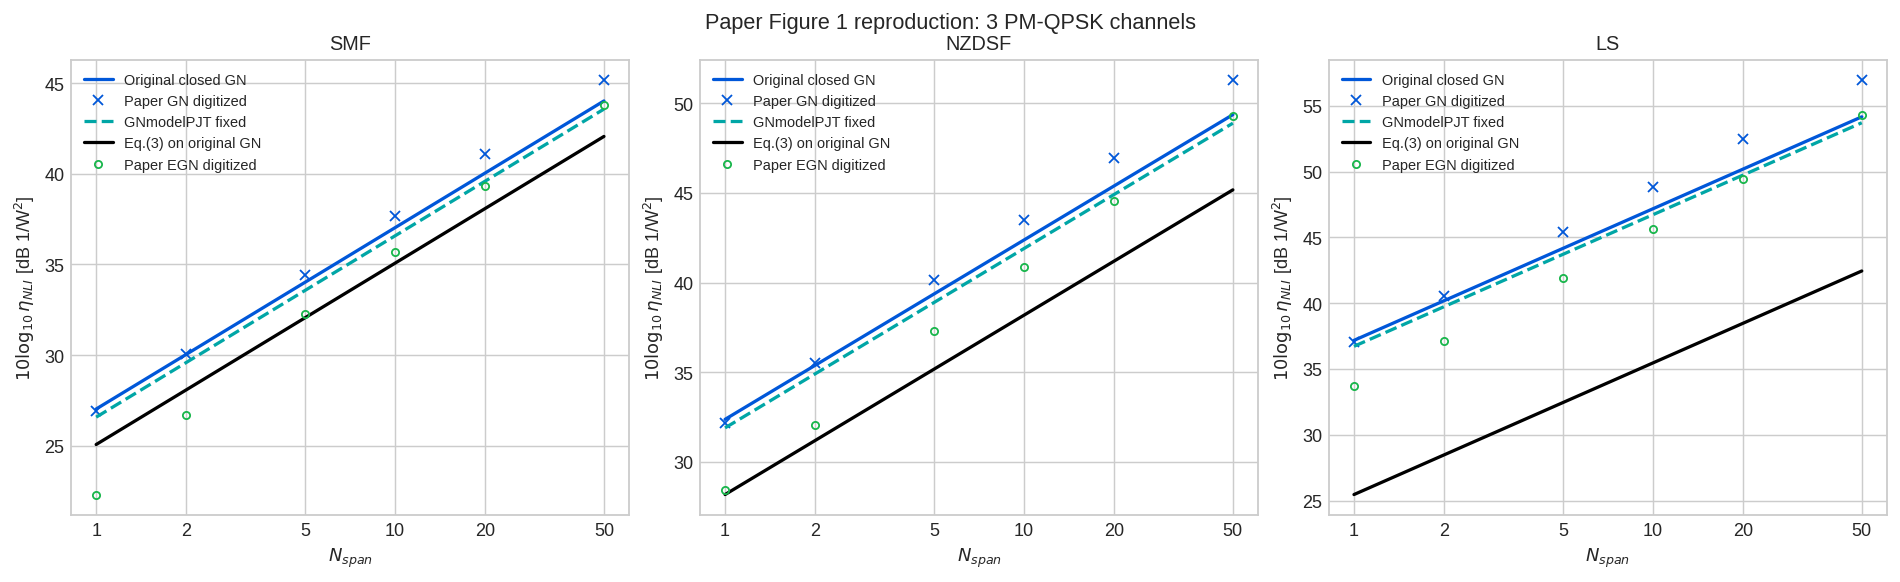

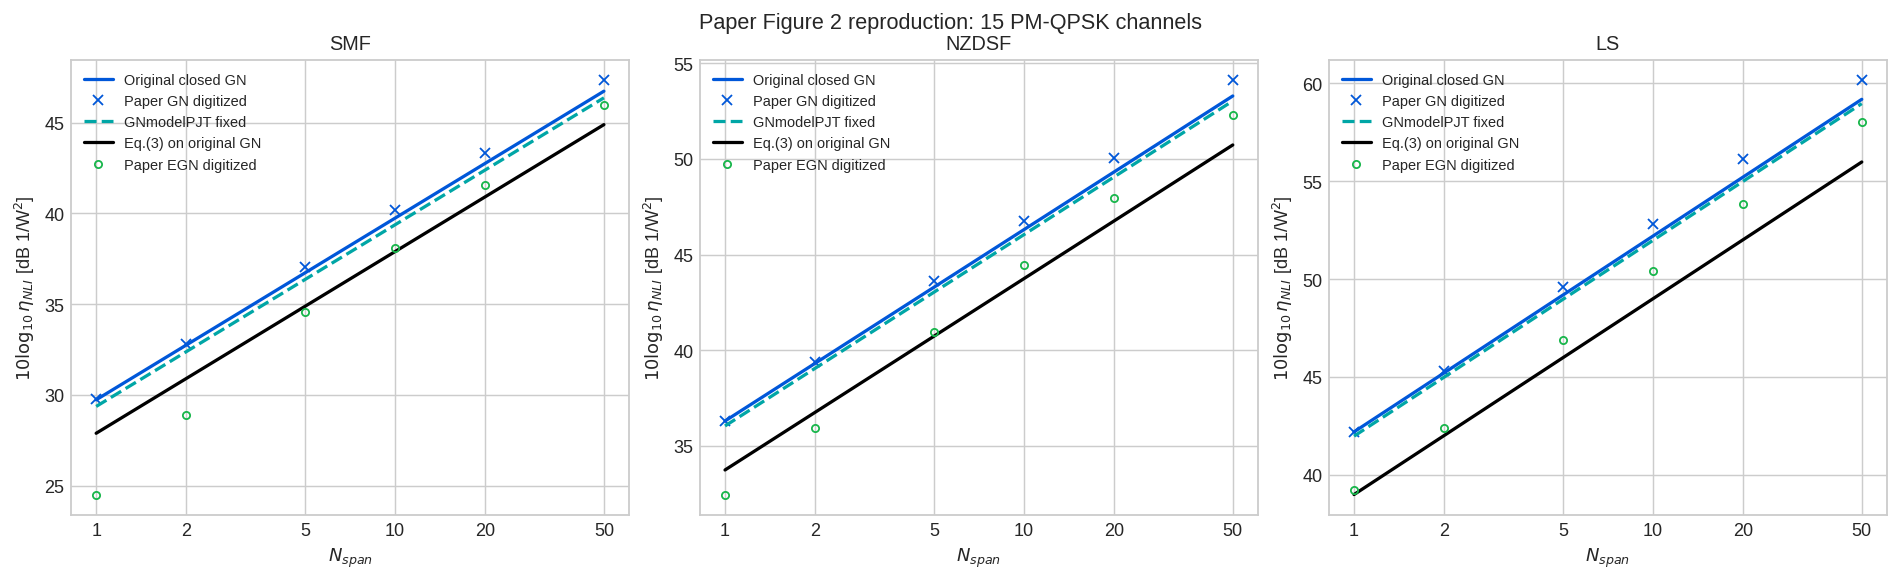

In [9]:
def plot_fig12(nch, figure_number):
    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2), sharex=True, layout="constrained")
    for ax, (name, pf) in zip(axes, PAPER_FIBRES.items()):
        gn = np.array([closed_gn_eta_total(nch, ns, pf) for ns in PAPER_NS])
        pjt = PAPER_NS*paper_modelpj_eta_span[(nch, name)]
        corr = np.array([paper_egn2_correction(nch, ns, pf) for ns in PAPER_NS])
        egn2 = np.maximum(gn-corr, gn*1e-8)
        ref = PAPER_FIG12[(nch,name)]
        ax.semilogx(PAPER_NS, lin_to_db(gn), "-", color="#0057d9", label="Original closed GN")
        ax.semilogx(PAPER_NS, ref["GN"], "x", ms=6, color="#0057d9", label="Paper GN digitized")
        ax.semilogx(PAPER_NS, lin_to_db(pjt), "--", color="#00a6a6", label="GNmodelPJT fixed")
        ax.semilogx(PAPER_NS, lin_to_db(egn2), "-", color="black", label="Eq.(3) on original GN")
        ax.semilogx(PAPER_NS, ref["EGN"], "o", ms=4, mfc="none", color="#18b64b", label="Paper EGN digitized")
        ax.set_xticks(PAPER_NS, labels=PAPER_NS)
        ax.set_title(name)
        ax.set_xlabel(r"$N_{span}$")
        ax.set_ylabel(r"$10\log_{10}\eta_{NLI}$ [dB 1/W$^2$]")
        ax.legend()
    fig.suptitle(f"Paper Figure {figure_number} reproduction: {nch} PM-QPSK channels", y=1.03)
    plt.show()

plot_fig12(3, 1)
plot_fig12(15, 2)

## 5. 논문 Figure 3: maximum system reach 재현

논문 조건:

- 15 channels, 32 GBaud, roll-off 0.05, spacing 33.6/35/40/45/50 GHz, EDFA NF=5 dB
- PM-QPSK: span 120 km, target BER $1.7\times10^{-3}$
- PM-16QAM: span 85 km, target BER $2.0\times10^{-3}$
- 두 경우 모두 FEC 임계 대비 2-dB OSNR margin
- PSCF $(0.17,20.1,0.8)$, SMF $(0.20,16.7,1.3)$, NZDSF $(0.22,3.8,1.5)$, LS $(0.22,-1.8,2.2)$

논문과 같은 per-polarization convention으로 $P_{ASE}=h\nu(F/2)R_s(G-1)$를 사용한다. 최적 launch는

$$P_{opt}=\left(\frac{P_{ASE}}{2\eta_{span}}\right)^{1/3},\qquad
N_{max}=\frac{1}{SNR_{req}(P_{ASE}/P_{opt}+\eta_{span}P_{opt}^2)}.$$

BER 근사는 QPSK $BER=\tfrac12\operatorname{erfc}(\sqrt{SNR/2})$, Gray 16QAM $BER\approx\tfrac38\operatorname{erfc}(\sqrt{SNR/10})$를 사용한다.

In [10]:
PAPER_REACH_FIBRES = {
    "PSCF": PaperFibre("PSCF", 0.17, 20.1, 0.8),
    "SMF": PaperFibre("SMF", 0.20, 16.7, 1.3),
    "NZDSF": PaperFibre("NZDSF", 0.22, 3.8, 1.5),
    "LS": PaperFibre("LS", 0.22, -1.8, 2.2),
}
PAPER_SPACING_GHZ = np.array([33.6, 35, 40, 45, 50])

# Digitized top curve (SIM marker group) and bottom GN curve from the supplied PDF.
PAPER_FIG3 = {
 "QPSK": {
  "PSCF":{"SIM":[65.30,65.85,68.66,70.11,70.99],"GN":[58.95,59.69,61.98,63.29,64.62]},
  "SMF":{"SIM":[27.79,28.37,29.46,30.21,30.78],"GN":[25.14,25.67,26.54,27.33,27.90]},
  "NZDSF":{"SIM":[12.46,12.77,13.60,14.15,14.88],"GN":[10.99,11.22,11.85,12.35,12.62]},
  "LS":{"SIM":[8.32,8.63,9.48,9.92,10.22],"GN":[7.01,7.18,7.69,7.97,8.20]}},
 "16QAM": {
  "PSCF":{"SIM":[35.59,35.59,37.85,38.80,39.63],"GN":[32.02,32.48,33.64,34.36,34.97]},
  "SMF":{"SIM":[17.41,17.72,18.91,19.38,19.80],"GN":[16.00,16.22,16.87,17.29,17.59]},
  "NZDSF":{"SIM":[8.65,8.87,9.60,10.01,10.25],"GN":[7.74,7.91,8.31,8.61,8.85]},
  "LS":{"SIM":[5.68,5.85,6.42,6.78,7.02],"GN":[4.97,5.07,5.41,5.64,5.80]}},
}

SNR_REQ = {
    "QPSK": 2*erfcinv(2*1.7e-3)**2*db_to_lin(2),
    "16QAM": 10*erfcinv((8/3)*2.0e-3)**2*db_to_lin(2),
}
SPAN_BY_MOD = {"QPSK": 120.0, "16QAM": 85.0}

def paper_reach_original(mod, pf, spacing_ghz):
    span = SPAN_BY_MOD[mod]
    eta = closed_gn_eta_total(15, 1, pf, span_km=span,
                              spacing_hz=spacing_ghz*1e9)
    gain = db_to_lin(pf.alpha_db_km*span)
    nu = C_M_PER_S/1550e-9
    pase = H_PLANCK*nu*(db_to_lin(5.0)/2)*32e9*(gain-1)
    popt = (pase/(2*eta))**(1/3)
    inv_snr_per_span = pase/popt+eta*popt**2
    return float(1/(SNR_REQ[mod]*inv_snr_per_span)), float(popt)

fig3_rows = []
fig3_predictions = {}
for mod in ("QPSK", "16QAM"):
    fig3_predictions[mod] = {}
    for name, pf in PAPER_REACH_FIBRES.items():
        pred = np.array([paper_reach_original(mod, pf, df)[0]
                         for df in PAPER_SPACING_GHZ])
        popt = np.array([paper_reach_original(mod, pf, df)[1]
                         for df in PAPER_SPACING_GHZ])
        fig3_predictions[mod][name] = pred
        ref = np.array(PAPER_FIG3[mod][name]["SIM"])
        err_db = 10*np.log10(pred/ref)
        fig3_rows.append({
            "Modulation": mod, "Fibre": name,
            "reach RMSE [dB]": np.sqrt(np.mean(err_db**2)),
            "reach bias [dB]": np.mean(err_db),
            "max |reach error| [dB]": np.max(np.abs(err_db)),
            "Popt @33.6GHz [dBm/ch]": w_to_dbm(popt[0]),
        })

fig3_metrics = pd.DataFrame(fig3_rows)
display(pd.DataFrame({"Modulation": list(SNR_REQ),
                      "Required SNR incl. margin [dB]": [lin_to_db(SNR_REQ[m]) for m in SNR_REQ]}))
display(fig3_metrics.round(3))

,Modulation,Required SNR incl. margin [dB]
0,QPSK,11.334535
1,16QAM,17.889882


,Modulation,Fibre,reach RMSE [dB],reach bias [dB],max |reach error| [dB],Popt @33.6GHz [dBm/ch]
0,QPSK,PSCF,0.072,0.068,0.104,-0.207
1,QPSK,SMF,0.056,-0.052,0.079,-0.380
2,QPSK,NZDSF,0.280,-0.272,0.365,-1.614
3,QPSK,LS,0.550,-0.541,0.647,-3.577
4,16QAM,PSCF,0.242,0.237,0.318,-2.151
5,16QAM,SMF,0.140,0.122,0.220,-2.690
6,16QAM,NZDSF,0.107,-0.068,0.153,-4.164
7,16QAM,LS,0.254,-0.233,0.337,-6.127


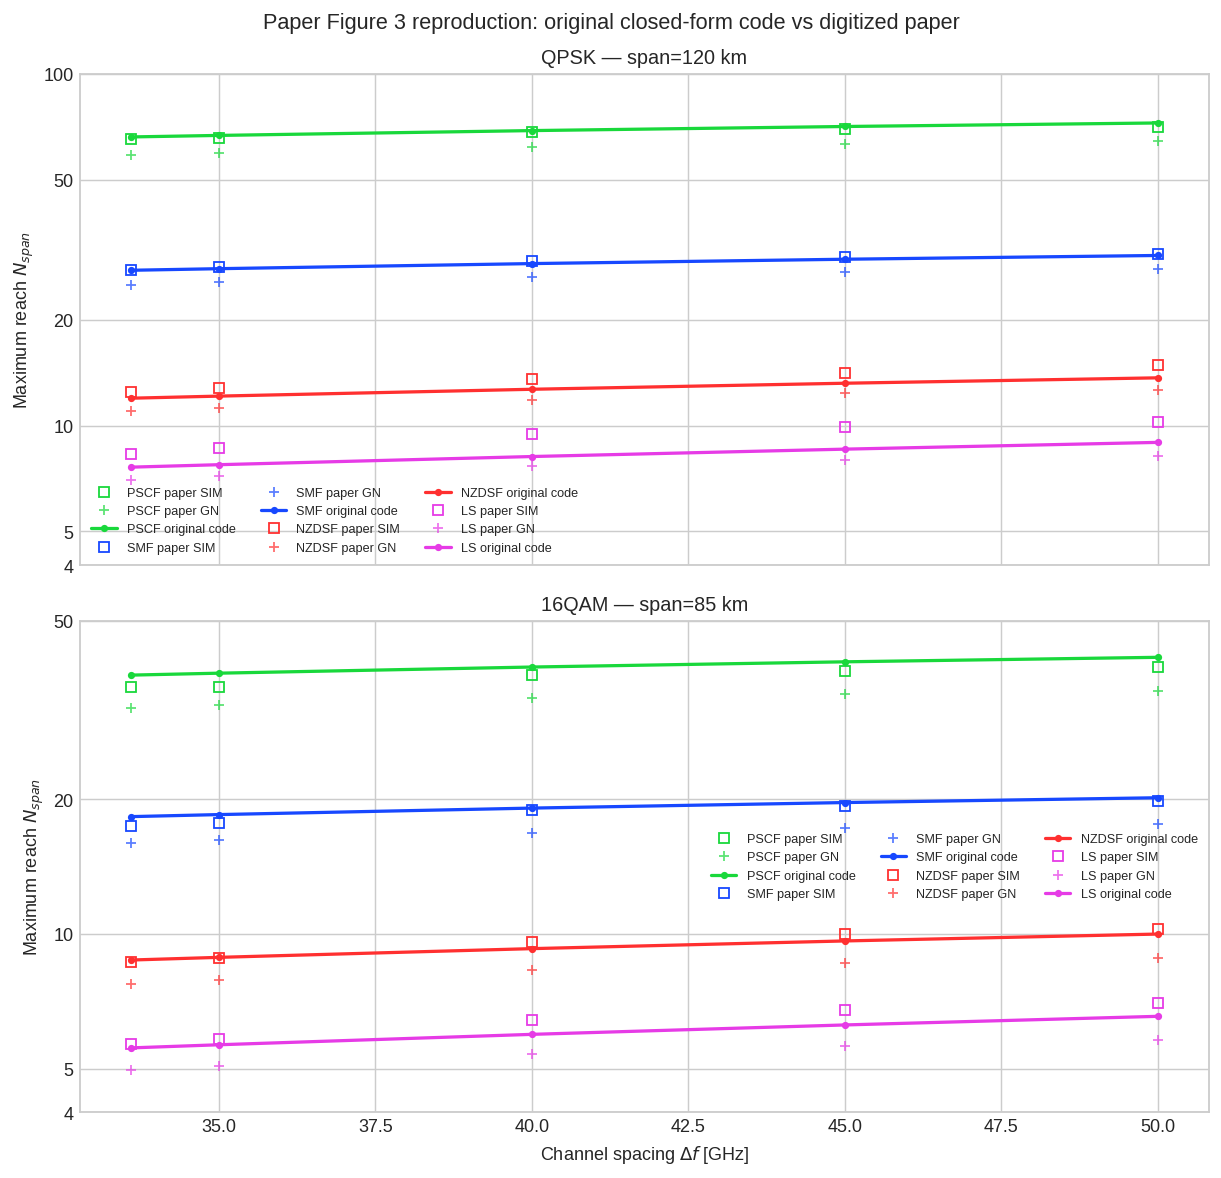

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(9.5, 9.2), sharex=True)
colors = {"PSCF":"#19d83b", "SMF":"#1748ff", "NZDSF":"#ff3030", "LS":"#e63be6"}
for ax, mod in zip(axes, ("QPSK", "16QAM")):
    for name in PAPER_REACH_FIBRES:
        ax.semilogy(PAPER_SPACING_GHZ, PAPER_FIG3[mod][name]["SIM"],
                    "s", mfc="none", color=colors[name], label=f"{name} paper SIM")
        ax.semilogy(PAPER_SPACING_GHZ, PAPER_FIG3[mod][name]["GN"],
                    "+", color=colors[name], alpha=.7, label=f"{name} paper GN")
        ax.semilogy(PAPER_SPACING_GHZ, fig3_predictions[mod][name],
                    "-o", ms=3, color=colors[name], label=f"{name} original code")
    ax.set_ylabel(r"Maximum reach $N_{span}$")
    ax.set_title(f"{mod} — span={SPAN_BY_MOD[mod]:.0f} km")
    ax.set_yticks([4,5,10,20,50,100] if mod=="QPSK" else [4,5,10,20,50])
    ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
    ax.legend(ncol=3, fontsize=7)
axes[-1].set_xlabel(r"Channel spacing $\Delta f$ [GHz]")
fig.suptitle("Paper Figure 3 reproduction: original closed-form code vs digitized paper")
fig.tight_layout()
plt.show()

## 6. 해석 시 주의사항

1. **Figure 1·2는 NLI 계수 검증**이다. 원 폐형식의 $N_s\eta_{span}$ 누적은 고분산·다채널에서 잘 맞지만, 저분산/소채널의 coherent accumulation을 작게 예측한다.
2. **Figure 3는 end-to-end reach 검증**이다. ASE, optimum launch, BER threshold까지 함께 작용하므로 Figure 1·2보다 더 직접적인 시스템 성능 검증이다.
3. **GGN(flat)=GN**은 성공 조건이다. 두 모델의 차이가 거의 0이면 power-profile 이식이 이론적으로 일관된 것이다.
4. **GGN과 EGN은 대체 관계가 아니다.** SRS가 없는 논문 조건에서 GGN을 추가해도 modulation-format correction은 생기지 않는다.
5. **Eq. (3) 차감은 base GN의 coherent-$N_s$ 동작을 전제로 한다.** 원 폐형식에 무조건 붙이는 방식은 LS 3채널에서 실패하므로, 논문 EGN 재현용과 해저 GDF 운용용 모델을 별도 검증해야 한다.
6. **39채널 Cartesian 적분의 절대값은 grid-sensitive하다.** 이 노트북의 321-point 값은 저장소 방식의 계산비용/수렴 문제를 드러내기 위한 진단값이다. 절대 $\eta$ 기준으로 사용할 때는 MATLAB 기본 1-GHz 수준 grid, channel-wise quadrature 또는 adaptive/hyperbolic 적분으로 수렴 검사를 먼저 해야 한다.

In [12]:
# ----------------------------- Final automatic report -----------------------------
orig_fig12 = fig12_metrics[fig12_metrics["Comparison"] == "Original closed GN vs paper GN"]
fig12_weighted_rmse = float(np.sqrt(np.average(orig_fig12["RMSE [dB]"]**2)))
fig12_mean_bias = float(orig_fig12["bias [dB]"].mean())
fig12_max = float(orig_fig12["max |error| [dB]"].max())

all_fig3_err = []
for mod in ("QPSK", "16QAM"):
    for name in PAPER_REACH_FIBRES:
        pred = fig3_predictions[mod][name]
        ref = np.array(PAPER_FIG3[mod][name]["SIM"])
        all_fig3_err.extend(10*np.log10(pred/ref))
all_fig3_err = np.asarray(all_fig3_err)
fig3_all_rmse = float(np.sqrt(np.mean(all_fig3_err**2)))
fig3_all_bias = float(np.mean(all_fig3_err))
fig3_all_max = float(np.max(np.abs(all_fig3_err)))

tilt_change = benchmark_df[benchmark_df["Model"] == "GNmodelPJT GGN 2-dB tilt"][[
    "Fibre", "delta eta vs numeric GN [dB]", "peak GSNR [dB]"
]].copy()

print("="*88)
print("FINAL INPUT VALUES")
print("="*88)
print("[Original submarine system]")
print(system_input_table.to_string(index=False))
print("\n[Original fibres]")
print(fibre_input_table.to_string(index=False))
print("\n[Paper Fig.1/2] Rs=32 GBaud, roll-off=0.05, spacing=33.6 GHz, span=100 km, Nch=3/15")
print("[Paper Fig.3] NF=5 dB, QPSK span=120 km, 16QAM span=85 km, spacing=33.6..50 GHz")

print("\n"+"="*88)
print("FINAL OUTPUT VALUES")
print("="*88)
print(f"GNmodelPJT GN vs flat-GGN equivalence: max |delta eta| = {flat_equiv_error_db.max():.3f} dB")
print(f"Paper Fig.1/2 original-GN coefficient: RMSE = {fig12_weighted_rmse:.3f} dB, "
      f"mean bias = {fig12_mean_bias:.3f} dB, max panel point error = {fig12_max:.3f} dB")
print(f"Paper Fig.3 original-code reach vs SIM: RMSE = {fig3_all_rmse:.3f} dB, "
      f"bias = {fig3_all_bias:.3f} dB, max |error| = {fig3_all_max:.3f} dB")
print("\n[GGN 2-dB edge-to-edge tilt stress test]")
print(tilt_change.round(3).to_string(index=False))

verdict = rf'''
### 최종 시사점

- **Figure 3 시스템 도달거리 정밀도는 높다.** 제공 PDF의 SIM 좌표 대비 전체 RMSE는 **{fig3_all_rmse:.3f} dB-reach**, 최대 오차는 **{fig3_all_max:.3f} dB**다. 따라서 논문 조건 범위에서는 원 코드의 폐형식 GN/GDF 경로가 시스템 reach를 실용적으로 유사하게 산출한다.
- **Figure 1·2 NLI 계수 정밀도는 조건 의존적이다.** GN 곡선의 panel-level 통합 RMSE는 **{fig12_weighted_rmse:.3f} dB**, 평균 편향은 **{fig12_mean_bias:.3f} dB**다. 가장 큰 오차는 저분산 LS·3채널처럼 coherent accumulation이 강한 조건에서 발생한다.
- **GNmodelPJT 이식 검증:** 수정한 Cartesian GN과 flat-profile GGN의 최대 차이는 **{flat_equiv_error_db.max():.3f} dB**로, flat/no-SRS에서 두 모델이 같아야 한다는 이론과 부합한다.
- **수치 수렴 주의:** 39채널 Cartesian 적분은 주파수 grid에 민감하므로 표의 coarse-grid 절대 $\eta$를 논문 정답으로 해석하면 안 된다. 모델 간 power-profile 영향은 동일 grid의 GN 대비 차이로 비교하고, 절대값은 반드시 grid refinement 후 사용한다.
- **저장소 원문을 그대로 다중 span에 쓰면 안 된다.** `GNLI_f.m`의 imaginary-sine span factor와 `GGNLI_f.m`의 누락된 `Ns` 누적은 수정이 필요하다. 이 노트북은 원문 진단값과 수정 구현을 모두 남겼다.
- **EGN 보정의 적용 한계:** 논문 Eq. (3)은 coherent GN base를 전제로 한다. 원 코드의 선형 $N_s\eta_{{span}}$에 단순 차감하면 특히 LS 3채널에서 논문 EGN과 불일치한다. GGN(SRS)도 EGN(변조 통계)을 대체하지 않는다.

**종합 판정:** 작성 코드는 논문 Figure 3형 시스템 성능 예측에는 강한 정밀도를 보이며, Figure 1·2형 NLI 계수 자체는 고분산/다채널에서 양호하다. 다만 저분산·소채널·coherent 다중-span 또는 강한 SRS 조건으로 확장할 때는 수정 GN/GGN과 정식 EGN base model의 추가 검증이 필요하다.
'''
display(Markdown(verdict))

assert flat_equiv_error_db.max() < 0.5, "Flat GGN should agree with GN within numerical-grid tolerance."
assert fig3_all_rmse < 0.5, "Paper Figure 3 reach RMSE exceeded the validation target."
print("\nFinal validation assertions: PASS")

FINAL INPUT VALUES
[Original submarine system]
     System input       Value     Unit
       wavelength 1550.000000       nm
               NF    4.500000       dB
               Rs  100.000000    GBaud
  channel spacing  112.500000      GHz
optical bandwidth    4.300000      THz
    effective Nch   38.222222 channels
      PFE voltage   18.000000       kV
      fibre pairs   12.000000    pairs

[Original fibres]
              Fibre  alpha [dB/km]  D [ps/nm/km]  gamma [1/W/km]  Aeff [um2]  IMI [dB/km]
          DNANF HCF          0.075           3.2          0.0005         NaN        -52.0
      SMF (G.652.D)          0.180          18.0          1.3000        85.0          NaN
G.654.E (SCUBA 110)          0.150          21.0          0.8100       110.0          NaN

[Paper Fig.1/2] Rs=32 GBaud, roll-off=0.05, spacing=33.6 GHz, span=100 km, Nch=3/15
[Paper Fig.3] NF=5 dB, QPSK span=120 km, 16QAM span=85 km, spacing=33.6..50 GHz

FINAL OUTPUT VALUES
GNmodelPJT GN vs flat-GGN equivalence


### 최종 시사점

- **Figure 3 시스템 도달거리 정밀도는 높다.** 제공 PDF의 SIM 좌표 대비 전체 RMSE는 **0.261 dB-reach**, 최대 오차는 **0.647 dB**다. 따라서 논문 조건 범위에서는 원 코드의 폐형식 GN/GDF 경로가 시스템 reach를 실용적으로 유사하게 산출한다.
- **Figure 1·2 NLI 계수 정밀도는 조건 의존적이다.** GN 곡선의 panel-level 통합 RMSE는 **0.962 dB**, 평균 편향은 **-0.670 dB**다. 가장 큰 오차는 저분산 LS·3채널처럼 coherent accumulation이 강한 조건에서 발생한다.
- **GNmodelPJT 이식 검증:** 수정한 Cartesian GN과 flat-profile GGN의 최대 차이는 **0.000 dB**로, flat/no-SRS에서 두 모델이 같아야 한다는 이론과 부합한다.
- **수치 수렴 주의:** 39채널 Cartesian 적분은 주파수 grid에 민감하므로 표의 coarse-grid 절대 $\eta$를 논문 정답으로 해석하면 안 된다. 모델 간 power-profile 영향은 동일 grid의 GN 대비 차이로 비교하고, 절대값은 반드시 grid refinement 후 사용한다.
- **저장소 원문을 그대로 다중 span에 쓰면 안 된다.** `GNLI_f.m`의 imaginary-sine span factor와 `GGNLI_f.m`의 누락된 `Ns` 누적은 수정이 필요하다. 이 노트북은 원문 진단값과 수정 구현을 모두 남겼다.
- **EGN 보정의 적용 한계:** 논문 Eq. (3)은 coherent GN base를 전제로 한다. 원 코드의 선형 $N_s\eta_{span}$에 단순 차감하면 특히 LS 3채널에서 논문 EGN과 불일치한다. GGN(SRS)도 EGN(변조 통계)을 대체하지 않는다.

**종합 판정:** 작성 코드는 논문 Figure 3형 시스템 성능 예측에는 강한 정밀도를 보이며, Figure 1·2형 NLI 계수 자체는 고분산/다채널에서 양호하다. 다만 저분산·소채널·coherent 다중-span 또는 강한 SRS 조건으로 확장할 때는 수정 GN/GGN과 정식 EGN base model의 추가 검증이 필요하다.



Final validation assertions: PASS


## 7. 출처

- [원 Colab](https://github.com/kimheeseo/LSCNS/blob/main/hcf_smf_g654e_optimal_gsnr_span_repeater_IMI_break.ipynb)
- [GNmodelPJT GNLI_f_hyp.m](https://github.com/kimheeseo/LSCNS/blob/main/GNmodelPJT/GN_model/GNLI_f_hyp.m)
- [GNmodelPJT GGNLI_f_3.m](https://github.com/kimheeseo/LSCNS/blob/main/GNmodelPJT/GGN_model/GGNLI_f_3.m)
- P. Poggiolini, Y. Jiang, A. Carena, F. Forghieri, “A Simple and Accurate Closed-Form EGN Model Formula,” 제공된 `2.pdf`.

재현성을 위해 논문 디지털화 기준값과 모든 입력 파라미터를 노트북 안에 명시했다. 더 높은 픽셀 정밀도가 필요하면 원 논문의 벡터 PDF/원 데이터로 `PAPER_FIG12`, `PAPER_FIG3` 배열만 교체하면 된다.